In [7]:
from pathlib import Path

# Define the base path (current working folder is transfer_learning)
BASE = Path.cwd()

# Path to the low-Mw scaled training dataset
train_path = BASE / "artifacts" / "final_train_df_scaled.csv"

print("Int-Mw dataset path:", train_path)

Int-Mw dataset path: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/transfer_learning/artifacts/final_train_df_scaled.csv


In [8]:
import pandas as pd

int_df = pd.read_csv(train_path)
int_df.head()


,SMILES,MP,MW,MP_category_default,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...,-20.0,624.106,Low,1.799400,1.799413,16.894265,-6.133933,-2.010495,3.352459,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
1,CCc1ncc[nH]1,82.0,96.133,Intermediate,-1.796152,-1.796104,1.246187,1.090090,-0.125444,-0.563987,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
2,S=C(N(C)C)Sc1ccc2c(c1)cccc2,114.0,247.388,Intermediate,-1.386201,-1.386157,1.027658,1.017238,-0.104357,-0.451964,...,4.528925,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
3,Nc1nc(N)nc(n1)c1ccccc1,227.0,187.206,Intermediate,-1.328157,-1.328114,-0.480411,0.514485,0.688746,-0.490529,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
4,NCCNc1ccc(cn1)[N+](=O)[O-],127.0,182.183,Intermediate,0.193419,0.193447,-0.722118,0.097043,-0.352533,-0.530083,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273


RDKit feature matrix shape: (17625, 202)


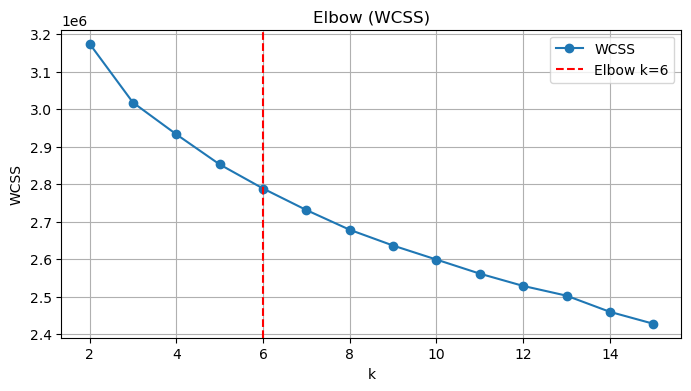

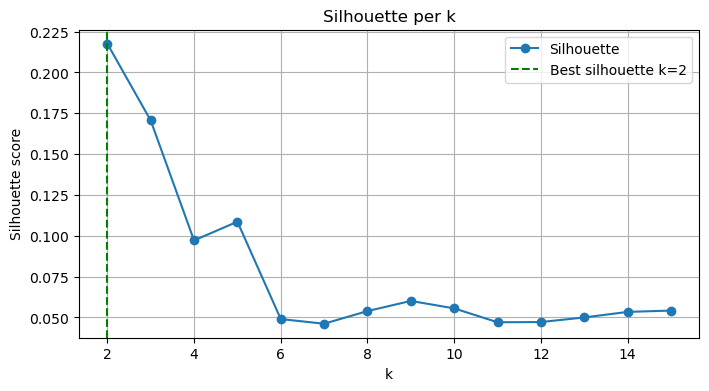

Elbow k: 6 | Best silhouette k: 2 | Selected k_opt: 6

Assigned Structure_Cluster using RDKit features with k=6.
                                              SMILES  Structure_Cluster
0  FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...                  1
1                                       CCc1ncc[nH]1                  5
2                        S=C(N(C)C)Sc1ccc2c(c1)cccc2                  3
3                             Nc1nc(N)nc(n1)c1ccccc1                  2
4                         NCCNc1ccc(cn1)[N+](=O)[O-]                  2

✅ Clustered Low-Mw dataset saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/transfer_learning/artifacts/final_train_MP_scaled_clustered.csv


In [9]:
# ========= Clustering RDKit features for Int-Mw data =========
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# ---------------------------------------------------------------------
# 1) Load Int-Mw scaled dataset
# ---------------------------------------------------------------------
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"

# ---------------------------------------------------------------------
# 2) Select RDKit features only
# ---------------------------------------------------------------------
# Exclude non-feature columns
exclude_cols = ["SMILES", "MP", "embeddings", "MW", "MP_category_default"]
rdk_cols = [c for c in int_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(int_df[c])]

X_rdk_scaled = int_df[rdk_cols].values
print(f"RDKit feature matrix shape: {X_rdk_scaled.shape}")

# ---------------------------------------------------------------------
# 3) Function: Find optimal k for KMeans
# ---------------------------------------------------------------------
def find_optimal_clusters_rdk(X_scaled, max_k=15, random_state=0, plot=True):
    ks, wcss, sils = list(range(2, max_k + 1)), [], []
    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        try:
            sils.append(silhouette_score(X_scaled, labels))
        except Exception:
            sils.append(np.nan)

    kn = KneeLocator(ks, wcss, curve="convex", direction="decreasing")
    k_elbow = kn.elbow
    k_sil = ks[int(np.nanargmax(sils))] if np.isfinite(sils).any() else None
    k_opt = k_elbow if k_elbow is not None else k_sil

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, wcss, marker="o", label="WCSS")
        if k_elbow is not None:
            ax.axvline(k_elbow, linestyle="--", color="r", label=f"Elbow k={k_elbow}")
        ax.set(xlabel="k", ylabel="WCSS", title="Elbow (WCSS)")
        ax.grid(True); ax.legend(); plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, sils, marker="o", label="Silhouette")
        if k_sil is not None:
            ax.axvline(k_sil, linestyle="--", color="g", label=f"Best silhouette k={k_sil}")
        ax.set(xlabel="k", ylabel="Silhouette score", title="Silhouette per k")
        ax.grid(True); ax.legend(); plt.show()

    print(f"Elbow k: {k_elbow} | Best silhouette k: {k_sil} | Selected k_opt: {k_opt}")
    return k_opt

# ---------------------------------------------------------------------
# 4) Find optimal number of clusters
# ---------------------------------------------------------------------
k_opt = find_optimal_clusters_rdk(X_rdk_scaled, max_k=15, random_state=0, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

# ---------------------------------------------------------------------
# 5) Apply KMeans clustering
# ---------------------------------------------------------------------
final_kmeans = KMeans(n_clusters=int(k_opt), init="k-means++", n_init=10, random_state=0)
int_df["Structure_Cluster"] = final_kmeans.fit_predict(X_rdk_scaled)

print(f"\nAssigned Structure_Cluster using RDKit features with k={k_opt}.")
print(int_df[["SMILES", "Structure_Cluster"]].head())

# ---------------------------------------------------------------------
# 6) Save the clustered dataset
# ---------------------------------------------------------------------
clustered_out_path = artifacts_dir / "final_train_MP_scaled_clustered.csv"
int_df.to_csv(clustered_out_path, index=False)
print(f"\n✅ Clustered Low-Mw dataset saved to: {clustered_out_path}")

In [10]:
# ========= 10-Fold Stratified CV (by Structure_Cluster) =========
from sklearn.model_selection import StratifiedKFold
import pandas as pd
from pathlib import Path
import numpy as np
import json

# ---------------------------------------------------------------------
# 1) Load clustered Low-Mw dataset
# ---------------------------------------------------------------------
BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
clustered_int_mw_path = artifacts_dir / "final_train_MP_scaled_clustered.csv"

df = pd.read_csv(clustered_int_mw_path)
print("Loaded clustered Int-MP dataset:", df.shape)

# ---------------------------------------------------------------------
# 2) Stratified 10-fold split
# ---------------------------------------------------------------------
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

folds = []
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["Structure_Cluster"])):
    folds.append({
        "fold": fold,
        "train_idx": train_idx.tolist(),
        "val_idx": val_idx.tolist()
    })

print(f"Generated {len(folds)} stratified folds.")

# ---------------------------------------------------------------------
# 4) Save folds to artifacts
# ---------------------------------------------------------------------
folds_path = artifacts_dir / "MP_folds.json"
with open(folds_path, "w") as f:
    json.dump(folds, f)

print(f"✅ Saved 10-fold stratified splits to: {folds_path}")


Loaded clustered Int-MP dataset: (17625, 207)
Generated 10 stratified folds.
✅ Saved 10-fold stratified splits to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/transfer_learning/artifacts/MP_folds.json


In [11]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
clustered_low_mw_path = artifacts_dir / "final_train_MP_scaled_clustered.csv"
folds_path = artifacts_dir / "MP_folds.json"

df = pd.read_csv(clustered_low_mw_path)
with open(folds_path, "r") as f:
    folds = json.load(f)

# Identify feature columns
exclude_cols = ["SMILES", "MP", "embeddings", "MW", "MP_category_default", "Structure_Cluster"]
rdkit_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

# Build fold_data dict for your objective()
def build_fold_data(df, feature_cols, folds):
    fold_data = {}
    for f in folds:
        fold_idx = f["fold"]
        train_idx, val_idx = f["train_idx"], f["val_idx"]
        fold_data[fold_idx] = {
            "X_train": df.loc[train_idx, feature_cols].values,
            "y_train": df.loc[train_idx, "MP"].values,
            "X_val":   df.loc[val_idx,   feature_cols].values,
            "y_val":   df.loc[val_idx,   "MP"].values,
        }
    return fold_data

fold_data = build_fold_data(df, rdkit_cols, folds)
print(f"Built fold_data for {len(fold_data)} folds.")

Built fold_data for 10 folds.


In [12]:
#Source: https://stackoverflow.com/questions/71998978/early-stopping-in-pytorch

# Early Stopping Based on Validation Loss
class EarlyStopper:

    # If the val loss has not been improved (i.e. stayed the same or got worse) for 20 epochs in a row, the training of the model is stopped.
    def __init__(self, patience=30, min_delta=0):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.counter = 0
        self.best_loss = float('inf')
        self.stop = False
        self.stop_epoch = None  # remember which epoch we stopped on (for plotting)

    def early_stop(self, val_loss, epoch=None):

        #For each epoch, checks if the validation loss has improved, we reset the counter.
        # We increase the counter if there is no improvement. Once the counter reaches the patience, we stop and remember the epoch.

        # Improvement means the loss decreased by more than min_delta
        if (self.best_loss - val_loss) > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            # No meaningful improvement this epoch
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                self.stop_epoch = epoch
        return self.stop

In [10]:
# Plot the loss curve 

import matplotlib.pyplot as plt

def plot_training_progress(train_losses, val_losses, early_stop_epoch=None, title="Training and Validation Loss"):
    #train_losses / val_losses: lists of per-epoch average loss values.
    #early_stop_epoch: integer epoch number (1-based) where early stopping triggered (optional).

    epochs = range(1, len(train_losses) + 1) 
    
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, val_losses,   label="Validation Loss")

    if early_stop_epoch is not None:
        plt.axvline(x=early_stop_epoch, color='r', linestyle='--', label="Early Stop")
    else:
    # draw line at last epoch
        plt.axvline(x=len(train_losses), color='gray', linestyle='--', label="End Epoch")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [13]:
import numpy as np
from pathlib import Path
import torch

# sklearn metrics
from sklearn.metrics import r2_score, root_mean_squared_error


def save_checkpoint(model, optimizer, epoch, train_loss, val_loss, y_train, y_val, val_loader, 
                   fold_idx, checkpoint_dir, checkpoint_tracking, is_final=False):
        
        
        # Calculate val predictions
        model.eval()
        all_preds = []
        with torch.no_grad():
            for xb, _ in val_loader:
                preds = model(xb).cpu().numpy()
                all_preds.append(preds)
        preds_val = np.concatenate(all_preds)
        
        # Calculate performance metrics from val predictions
        checkpoint_rmse = root_mean_squared_error(y_val, preds_val)
        checkpoint_r2 = r2_score(y_val, preds_val)
        checkpoint_q2 = 1 - np.sum((y_val - preds_val)**2) / np.sum((y_val - y_train.mean())**2)
        
        # Create checkpoint filename
        if is_final:
            checkpoint_filename = f"checkpoint_epoch_{epoch:03d}_final.pt"
        else:
            checkpoint_filename = f"checkpoint_epoch_{epoch:03d}.pt"
        
        checkpoint_path_full = Path(checkpoint_dir) / checkpoint_filename
        
        # Save the checkpoint
        checkpoint_data = {'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss, 'val_loss': val_loss, 'rmse': checkpoint_rmse, 'r2': checkpoint_r2, 'q2': checkpoint_q2,
            'fold_idx': fold_idx, 'is_final': is_final}
        torch.save(checkpoint_data, checkpoint_path_full)
        
        # Record info for spreadsheet
        checkpoint_info = {'Fold': fold_idx, 'Epoch': epoch, 'Checkpoint_Filename': checkpoint_filename, 'Checkpoint_Path': str(checkpoint_path_full),
            'Train_Loss': round(train_loss, 6), 'Val_Loss': round(val_loss, 6), 'RMSE': round(checkpoint_rmse, 6), 'R2': round(checkpoint_r2, 6), 
            'Q2': round(checkpoint_q2, 6), 'Is_Final': is_final}
        checkpoint_tracking.append(checkpoint_info)
        
        checkpoint_type = "Final" if is_final else "Regular"
        print(f"[Fold {fold_idx}] {checkpoint_type} checkpoint saved at epoch {epoch} - RMSE: {checkpoint_rmse:.4f}")
        return True
        

In [14]:
import torch
import torch.nn as nn

# since RMSE Loss is not in PyTorch, we define it here using MSELoss

class RMSELoss(nn.Module):
    def __init__(self, eps=1e-8):  

        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps      # eps: a small constant to avoid sqrt(0) or division by zero;  to prevent potential numerical instability or "division by zero" like issues if the MSE happens to be exactly zero 

    def forward(self, y_pred, y_true):
        mse = self.mse(y_pred, y_true)
        rmse = torch.sqrt(mse + self.eps)
        return rmse


In [15]:
# ==== Standard libraries ====
import copy
from pathlib import Path

# ==== Numerical ====
import numpy as np

# ==== PyTorch ====
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ==== sklearn metrics ====
from sklearn.metrics import r2_score, root_mean_squared_error

# ==== Your custom modules ====
from NN_model import ImprovedNN   # make sure NN_model/ folder is in sys.path
import copy 

def evaluate_fold(trial, fold_idx, X_train_scaled, y_train, X_val_scaled, y_val, hidden_layers, learning_rate, batch_size, dropout_rate, weight_decay, max_epochs = 10**9, patience = 30, min_delta = 0, X_test_scaled=None, y_test=None, save_checkpoints=False, checkpoint_dir="checkpoints", save_every_n_epochs=15):

    # Set device to CPU
    device = torch.device("cpu")
    print(f"Fold {fold_idx}: Training on cpu")

    #Setup checkpoint directory and tracking list
    checkpoint_tracking = []  # Empty list to track performance metrics for model checkpointing
    
    # If saving checkpoints is true, we are creating the path checkpoints/fold_{fold_idx}
    if save_checkpoints:
        checkpoint_path = Path(checkpoint_dir)
        checkpoint_path.mkdir(parents=True, exist_ok=True)
        fold_checkpoint_dir = checkpoint_path / f"fold_{fold_idx}"
        fold_checkpoint_dir.mkdir(parents=True, exist_ok=True)
        print(f"Checkpoints will be saved to: {fold_checkpoint_dir}")

    # Convert data to tensors and move to device
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)      # reshape the targets to column vectors to match the model’s predictions and prevent PyTorch from doing sneaky broadcasting
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32).to(device)


    # Load the training df
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    
    #Load the val df 
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)   
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    #model, optimizer  scheduler, loss (set up training components)
    model     = ImprovedNN(input_size = X_train_scaled.shape[1], hidden_layers=hidden_layers, dropout_rate = dropout_rate).to(device) #A new model is created for each trial run with Optuna, the hyperparameters in each trial is chosen by Optuna, new instance of the model is created, and input size is determined by features in scaled training data, drop out rate is suggested by Optuna
    criterion = RMSELoss() # changed from HuberLoss to RMSELoss 
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay) #Optimizer adjusts the model's internal weights and biases, AdamW is an optimizer, model.parameters() tells optimizer what to optimize, lr = learning_rate uses suggested learning rate by Optuna, same for weight_decay                     
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10) #Automatically adjusts learning rate during training, mode = "min" monitors metric to minimize, factor = 0.5 if monitored metric doesn't improve for a certain amount of epochs reduce lr by 1/2, patience is number of epochs to wait before adjustment by factor 
                                               
    # Set up values for early stopping
    early_stopper = EarlyStopper(patience=patience, min_delta=min_delta)

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())

    train_losses, val_losses = [], []
    stop_epoch = None

        #-- Model Training ---
    for epoch in range(1, max_epochs + 1): ##for loop represemts the training process for a single model for the current trial, runs for 300 epochs, each epoch indicates that the model has run once, so 12 epoches means the model has been run 12 times 
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader: ##Put model into training mode (dropout turn on), loops over each batch (xb = input, yb = target)
            optimizer.zero_grad() #Clear out any old gradients (a gradient is a piece of information about how much much to change the weights)
            preds = model(xb) #make predictions
            loss  = criterion(preds, yb) #Calculate loss function
            loss.backward() #Back propogate
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5) #Prevents exploding gradients which causes the model to become unstable, limits how big the adjustments to weights can be 
            optimizer.step() #Uses calculated gradients to actually update model's weights and biases trying to reduce loss 
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # --- To validate the model ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = model(xb)
                loss  = criterion(preds, yb)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)   
       
        scheduler.step(val_loss)
        
        # Update best model if validation loss improves
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
        
        # Saves checkpoints every n epochs (and at epoch 1)
        if save_checkpoints and (epoch % save_every_n_epochs == 0 or epoch == 1):
            # Calculate metrics for this checkpoint
            save_checkpoint(model, optimizer, epoch, train_loss, val_loss, y_train, y_val, val_loader, fold_idx, fold_checkpoint_dir, checkpoint_tracking, is_final=False)

        # Check for early stopping
        should_stop = early_stopper.early_stop(val_loss, epoch=epoch)
        if should_stop:
            stop_epoch = early_stopper.stop_epoch
            print(f"[Fold {fold_idx}] Early stopping  at epoch {stop_epoch} (best Val Loss: {best_val_loss:.4f})")

            # Save final checkpoint on early stop (guarantee last snapshot)
            if save_checkpoints and epoch % save_every_n_epochs != 0 and epoch != 1:
                save_checkpoint(model, optimizer, epoch, train_loss, val_loss, y_train, y_val, 
                              val_loader, fold_idx, fold_checkpoint_dir, checkpoint_tracking, is_final=True)
            
            break

        # Log progress every 50 epochs or first epoch
        if epoch % 50 == 0 or epoch == 1:
            print(f"[Fold {fold_idx}] Epoch {epoch:4d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | ES {early_stopper.counter}/{patience}")
    
    # Load best model state (from epoch with lowest val loss)
    model.load_state_dict(best_state)
    model.eval()  

    # Save the checkpoint tracking spreadsheet for this fold
    if save_checkpoints and checkpoint_tracking:
        df_checkpoints = pd.DataFrame(checkpoint_tracking)
        spreadsheet_file = fold_checkpoint_dir / f"fold_{fold_idx}_checkpoints.csv"
        df_checkpoints.to_csv(spreadsheet_file, index=False)
        print(f"[Fold {fold_idx}] Checkpoint spreadsheet saved: {spreadsheet_file}")
        print(f"[Fold {fold_idx}] Total checkpoints saved: {len(checkpoint_tracking)}")
  

    # Final metrics calculation (using the best model)
    all_preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            preds = model(xb).cpu().numpy()
            all_preds.append(preds)
    preds_val = np.concatenate(all_preds)
    
    rmse = root_mean_squared_error(y_val, preds_val)
    r2 = r2_score(y_val, preds_val)
    q2 = 1 - np.sum((y_val - preds_val)**2) / np.sum((y_val - y_train.mean())**2)
 
    return rmse, r2, q2, model, train_losses, val_losses, stop_epoch

In [16]:
import time
import numpy as np
import torch

# Step 3: Hyperparameter optimization
trial_times = []

def objective(trial):
    # Suggest hyperparameters
    dropout_rate  = trial.suggest_float("dropout_rate",  0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay  = trial.suggest_float("weight_decay",  1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [16,32,64])

    # First hidden layer max 256
    h1 = trial.suggest_categorical("h1", [64, 96, 128, 160, 192, 224, 256])     # spread of “reasonable” widths: multiples of 32 or 64 up to 256
    h2 = max(h1 // 2, 4)    # 8: minimum width for hidden layers
    h3 = max(h2 // 2, 2)
    hidden_layers = [h1, h2, h3]    # set to 3 layers

    # Start trial timer
    start = time.perf_counter()
    device = torch.device("cpu")

    rmses = []

    # Run this hyperparameter combo across all folds
    for fold in range(10):
        X_train_scaled = fold_data[fold]["X_train"]
        y_train        = fold_data[fold]["y_train"]
        X_val_scaled   = fold_data[fold]["X_val"]
        y_val          = fold_data[fold]["y_val"]

        rmse, _, _, _,  _, _, _ = evaluate_fold(trial=trial, fold_idx=fold,X_train_scaled=X_train_scaled, y_train=y_train,
            X_val_scaled=X_val_scaled,   y_val=y_val, learning_rate=learning_rate, batch_size=batch_size, hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,   weight_decay=weight_decay, save_checkpoints=False)
        rmses.append(rmse)

    elapsed = (time.perf_counter() - start) / 60.0
    trial_times.append(elapsed)
    print(f"Trial {trial.number} finished in {elapsed:.2f} minutes")

    # Return the metric Optuna should minimize
    avg_rmse = float(np.mean(rmses))
    print(f"Trial{trial.number}: Average RMSE = {avg_rmse:.4f}")
    return avg_rmse

In [17]:
import time 
import torch
import optuna
from optuna.importance import get_param_importances
import optuna.visualization as vis 
import copy

device = torch.device("cpu")

def set_optuna_study(n_trials): 
    start_time = time.perf_counter()
    print("Setting up Optuna study...")
    
    # 1) Set up the Optuna study
    study = optuna.create_study(direction='minimize') #minimize return loss
    study.optimize(objective, n_trials=n_trials)  #CHANGE TO 100 AFTER TESTING
    
    # 2) Identify the best hyperparameters
    best_params = study.best_params #best_params holds the dropout, learning rate, and weight decay that gave the lowest best_val_loss
    print("Best hyperparameters:", best_params)
    
    end_time = time.perf_counter()
    elapsed_time = (end_time - start_time) / 60.0
    print(f"Optuna study completed in {elapsed_time:.2f} minutes")
    
    return best_params, study

fold_data = build_fold_data(df, rdkit_cols, folds)
best_params, study = set_optuna_study(n_trials=20) 

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-02 00:32:46,513] A new study created in memory with name: no-name-12678885-27fe-4327-ba74-557c3118113d


Setting up Optuna study...
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 137.3512 | Val Loss: 136.7166 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 58.1897 | Val Loss: 56.5421 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 41.1101 | Val Loss: 37.4513 | ES 0/30
[Fold 0] Epoch  150 | Train Loss: 39.8308 | Val Loss: 36.9752 | ES 2/30
[Fold 0] Early stopping  at epoch 178 (best Val Loss: 36.7839)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 137.0842 | Val Loss: 134.8095 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 50.3117 | Val Loss: 47.1052 | ES 0/30
[Fold 1] Epoch  100 | Train Loss: 40.5170 | Val Loss: 37.4118 | ES 7/30
[Fold 1] Epoch  150 | Train Loss: 39.1181 | Val Loss: 36.7608 | ES 20/30
[Fold 1] Epoch  200 | Train Loss: 39.0029 | Val Loss: 36.5749 | ES 0/30
[Fold 1] Early stopping  at epoch 230 (best Val Loss: 36.5749)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 136.7156 | Val Loss: 135.6839 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 49.8437 | Val 

[I 2026-03-02 01:02:50,297] Trial 0 finished with value: 37.06274976555766 and parameters: {'dropout_rate': 0.2329908889757773, 'learning_rate': 0.00014037012335965516, 'weight_decay': 1.6773930402852116e-05, 'batch_size': 64, 'h1': 160}. Best is trial 0 with value: 37.06274976555766.


[Fold 9] Early stopping  at epoch 260 (best Val Loss: 36.1976)
Trial 0 finished in 30.06 minutes
Trial0: Average RMSE = 37.0627
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 137.4909 | Val Loss: 137.4415 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 95.8814 | Val Loss: 95.8928 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 49.0959 | Val Loss: 45.3757 | ES 0/30
[Fold 0] Epoch  150 | Train Loss: 44.1434 | Val Loss: 39.8210 | ES 8/30
[Fold 0] Epoch  200 | Train Loss: 43.7064 | Val Loss: 38.8528 | ES 6/30
[Fold 0] Epoch  250 | Train Loss: 43.5742 | Val Loss: 38.7452 | ES 28/30
[Fold 0] Early stopping  at epoch 252 (best Val Loss: 38.4008)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 137.2783 | Val Loss: 135.5717 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 92.0109 | Val Loss: 89.8048 | ES 0/30
[Fold 1] Epoch  100 | Train Loss: 47.6371 | Val Loss: 41.4625 | ES 0/30
[Fold 1] Epoch  150 | Train Loss: 43.5740 | Val Loss: 38.2873 | ES 3/30
[Fold 1] Epoch  200 | Train Loss: 42

[I 2026-03-02 05:55:35,253] Trial 1 finished with value: 37.89690982882691 and parameters: {'dropout_rate': 0.3784723917215811, 'learning_rate': 6.0434169427015106e-05, 'weight_decay': 1.0641275822187914e-06, 'batch_size': 64, 'h1': 224}. Best is trial 0 with value: 37.06274976555766.


...

[Fold 9] Early stopping  at epoch 158 (best Val Loss: 35.2777)
Trial 17 finished in 32.86 minutes
Trial17: Average RMSE = 36.4259
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 134.1514 | Val Loss: 131.5670 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 42.2876 | Val Loss: 37.8083 | ES 8/30
[Fold 0] Epoch  100 | Train Loss: 39.7057 | Val Loss: 36.4821 | ES 6/30
[Fold 0] Epoch  150 | Train Loss: 39.5268 | Val Loss: 36.5645 | ES 28/30
[Fold 0] Early stopping  at epoch 152 (best Val Loss: 35.8246)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 135.1111 | Val Loss: 130.1898 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 43.7432 | Val Loss: 37.7125 | ES 4/30
[Fold 1] Epoch  100 | Train Loss: 41.3494 | Val Loss: 36.4859 | ES 1/30
[Fold 1] Epoch  150 | Train Loss: 40.9136 | Val Loss: 36.4775 | ES 2/30
[Fold 1] Early stopping  at epoch 178 (best Val Loss: 35.7338)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 133.8643 | Val Loss: 130.8580 | ES 0/30
[Fold 2] Epoch   

[I 2026-03-02 15:07:36,833] Trial 18 finished with value: 36.58104267602995 and parameters: {'dropout_rate': 0.36212010368317976, 'learning_rate': 0.0002671735349736122, 'weight_decay': 7.733202865004338e-06, 'batch_size': 32, 'h1': 256}. Best is trial 12 with value: 36.214753231091606.


[Fold 9] Early stopping  at epoch 211 (best Val Loss: 35.2845)
Trial 18 finished in 43.58 minutes
Trial18: Average RMSE = 36.5810
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 133.4128 | Val Loss: 130.9201 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 45.2723 | Val Loss: 38.1475 | ES 5/30
[Fold 0] Early stopping  at epoch 89 (best Val Loss: 36.3484)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 132.6131 | Val Loss: 127.2031 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 44.4702 | Val Loss: 37.8815 | ES 6/30
[Fold 1] Epoch  100 | Train Loss: 43.1786 | Val Loss: 38.1885 | ES 3/30
[Fold 1] Early stopping  at epoch 127 (best Val Loss: 36.7936)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 132.6063 | Val Loss: 128.1596 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 44.3452 | Val Loss: 36.5476 | ES 0/30
[Fold 2] Epoch  100 | Train Loss: 42.9773 | Val Loss: 36.3970 | ES 29/30
[Fold 2] Early stopping  at epoch 101 (best Val Loss: 36.1780)
Fold 3: Training on cpu
[Fo

[I 2026-03-02 15:18:32,696] Trial 19 finished with value: 37.56422095705747 and parameters: {'dropout_rate': 0.340547202271665, 'learning_rate': 0.0005317854740473593, 'weight_decay': 0.0005680018105441398, 'batch_size': 32, 'h1': 128}. Best is trial 12 with value: 36.214753231091606.


[Fold 9] Early stopping  at epoch 130 (best Val Loss: 35.9935)
Trial 19 finished in 10.93 minutes
Trial19: Average RMSE = 37.5642
Best hyperparameters: {'dropout_rate': 0.20146069933717134, 'learning_rate': 0.0009792209031958298, 'weight_decay': 0.0003127141407972552, 'batch_size': 32, 'h1': 192}
Optuna study completed in 885.77 minutes


In [41]:
# Save the best parameters

print("Best Trial Number:", study.best_trial.number)
print("  RMSE:", study.best_value)
print("  Params:", study.best_params)

Best Trial Number: 14
  RMSE: 31.966880168744314
  Params: {'dropout_rate': 0.38320113538059225, 'learning_rate': 0.0009445631572695242, 'weight_decay': 0.0006404528742319037, 'batch_size': 16, 'h1': 256}


In [ ]:
from pathlib import Path
import torch
import pandas as pd

# BASE and artifacts_dir should already be defined, but just in case:
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"

# Directory to store the final best models for each fold
best_models_dir = artifacts_dir / "MP_best_models"
best_models_dir.mkdir(parents=True, exist_ok=True)

# (Optional) directory to store checkpoints from this final run
final_ckpt_dir = BASE / "checkpoints_MP_best"
final_ckpt_dir.mkdir(parents=True, exist_ok=True)

# Make sure best_params exists (from your Optuna study)
print("Best hyperparameters from Optuna:", best_params)

# Helper to derive hidden layers from best_params (same logic as in objective)
def build_hidden_layers_from_best(best_params):
    h1 = best_params["h1"]
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    return [h1, h2, h3]

hidden_layers = build_hidden_layers_from_best(best_params)
dropout_rate  = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
weight_decay  = best_params["weight_decay"]
batch_size    = best_params["batch_size"]

print("Using hidden_layers:", hidden_layers)
print("dropout:", dropout_rate, "| lr:", learning_rate, "| wd:", weight_decay, "| batch_size:", batch_size)

# To keep track of metrics across folds
final_fold_metrics = []

# ---------- Final training loop for all 10 folds ----------
for fold in range(10):
    print(f"\n==================== Final training for fold {fold} ====================")
    
    X_train_scaled = fold_data[fold]["X_train"]
    y_train        = fold_data[fold]["y_train"]
    X_val_scaled   = fold_data[fold]["X_val"]
    y_val          = fold_data[fold]["y_val"]

    # Train this fold with the best hyperparameters
    rmse, r2, q2, model, train_losses, val_losses, stop_epoch = evaluate_fold(
        trial=None,                    # not needed for final run
        fold_idx=fold,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        X_val_scaled=X_val_scaled,
        y_val=y_val,
        hidden_layers=hidden_layers,
        learning_rate=learning_rate,
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        max_epochs=10**9,              # will stop via early-stopping anyway
        patience=30,
        min_delta=0.0,
        save_checkpoints=True,         # save checkpoints for this BEST config
        checkpoint_dir=final_ckpt_dir,
        save_every_n_epochs=15
    )

    # ---------- Save the final model for this fold ----------
    model_path = best_models_dir / f"MP_best_fold_{fold}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "hidden_layers": hidden_layers,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "fold_idx": fold,
            "rmse": rmse,
            "r2": r2,
            "q2": q2,
        },
        model_path,
    )
    print(f"[Fold {fold}] Saved best model to: {model_path}")

    # store metrics
    final_fold_metrics.append(
        {
            "Fold": fold,
            "RMSE": rmse,
            "R2": r2,
            "Q2": q2,
            "Stop_Epoch": stop_epoch,
            "Model_Path": str(model_path),
        }
    )

# ---------- Save a summary CSV of all folds ----------
metrics_df = pd.DataFrame(final_fold_metrics)
metrics_path = best_models_dir / "MP_best_models_summary.csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n✅ Saved summary of best models across folds to:", metrics_path)
print(metrics_df)


Best hyperparameters from Optuna: {'dropout_rate': 0.38320113538059225, 'learning_rate': 0.0009445631572695242, 'weight_decay': 0.0006404528742319037, 'batch_size': 16, 'h1': 256}
Using hidden_layers: [256, 128, 64]
dropout: 0.38320113538059225 | lr: 0.0009445631572695242 | wd: 0.0006404528742319037 | batch_size: 16

==================== Final training for fold 0 ====================
Fold 0: Training on cpu
Checkpoints will be saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/checkpoints_int_Mw_best/fold_0
[Fold 0] Regular checkpoint saved at epoch 1 - RMSE: 106.1394
[Fold 0] Epoch    1 | Train Loss: 126.9957 | Val Loss: 105.7333 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 15 - RMSE: 33.5823
[Fold 0] Regular checkpoint saved at epoch 30 - RMSE: 33.0599
[Fold 0] Regular checkpoint saved at epoch 45 - RMSE: 32.5848
[Fold 0] Epoch   50 | Train Loss: 35.1822 | Val Loss: 31.5489 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 60 - RMSE: 31.9089
[Fold 0] Regul

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from NN_model import ImprovedNN


# Define output path
df_test = pd.read_csv("../transfer_learning/artifacts/test_df_scaled.csv")


# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/int_MW_best_models/low_MW_best_fold_1.pt"

OUT_PRED_CSV = BASE / "artifacts/test_MP_predictions_RDKit_all.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.38320113538059225 # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "MP_category_default"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

# Add MP category to output df (so we can split metrics)
out_df = pd.DataFrame({
    "SMILES": smiles,
    "MP_category_default": df_test["MP_category_default"].astype(str).to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

# Save predictions
OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

# --------------------
# RMSE overall + by MP_category_default
# --------------------
rmse_total = float(np.sqrt(np.mean(out_df["error"] ** 2)))
print(f"\nTotal RMSE (all): {rmse_total:.3f}")

# Normalize labels just in case (low/Low/LOW etc.)
cat = out_df["MP_category_default"].str.strip().str.lower()

df_low = out_df[cat == "low"]
df_high = out_df[cat == "high"]

rmse_low = float(np.sqrt(np.mean(df_low["error"] ** 2))) if len(df_low) else np.nan
rmse_high = float(np.sqrt(np.mean(df_high["error"] ** 2))) if len(df_high) else np.nan

print(f"RMSE (MP_category_default = Low):  {rmse_low:.3f}  (n={len(df_low)})")
print(f"RMSE (MP_category_default = High): {rmse_high:.3f} (n={len(df_high)})")

Test rows: 1961
Features: 202

=== TEST METRICS ===
RMSE: 61.8611
MAE : 43.3691
R^2 : 0.5269

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/transfer_learning/artifacts/test_MP_predictions_RDKit_all.csv

Total RMSE (all): 61.861
RMSE (MP_category_default = Low):  59.998  (n=1885)
RMSE (MP_category_default = High): 97.249 (n=76)


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_7692/263529047.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=dev

In [ ]:
# Plotting optuna trial with RMSE

import matplotlib.pyplot as plt
import pandas as pd

# Collect data from your study
records = []
for t in study.trials:
    if t.value is not None:  # skip failed/pruned trials
        records.append({"trial": t.number, "rmse": t.value})

df = pd.DataFrame(records)

plt.figure(figsize=(8,5))
plt.plot(df["trial"], df["rmse"], marker="o")
plt.title("Optuna Trials vs Mean RMSE (10-Fold Average)")
plt.xlabel("Trial Number")
plt.ylabel("Average RMSE")
plt.grid(True)
plt.show()

In [ ]:
# For Each trial, save the model for each fold?
# when saving checkpoints, is it saving the whole model?
# differenc between epochs saving and the model saving



In [ ]:
# Load the best model (best trial, best fold)


# Grab the test data and run it